In [34]:
import numpy as np
from matplotlib import pyplot as plt

from functions.read_g4bl_data import readTraceData
from functions.set_plot_settings import setPlotSettings
from functions.calculate_fields import calculate_Br_analytic, calculate_Br_rotated

setPlotSettings(font=True)

# Directory:
# dir = 'study-single-coil/'
# dir = 'study-lattice-flipped/'
# dir = 'study-lattice-not-flipped/'
dir = 'study-channel/'

# Load data from output txt file:
file = dir+'g4bl-output/AllTracks.txt'

# Select event ID:
# eventID = -2 # reference
eventID = 1 # with initial conditions

### SET CONFIG PARAMS ###

# Number of solenoids in sim:
# n = 1
n = 18

# Distance between coil centers [mm]:
d = 400

# Length of coil [mm]:
L = 100

In [35]:
# Define function to plot lines indicating solenoid centers:
def plot_solenoids(n):
    for i in range(n):
        plt.axvline(x=500+i*d,color='black',alpha=0.1)

In [36]:
# Read in data:
data = readTraceData(file)
data = data[data['EventID'] == eventID]

### Fields in lab frame

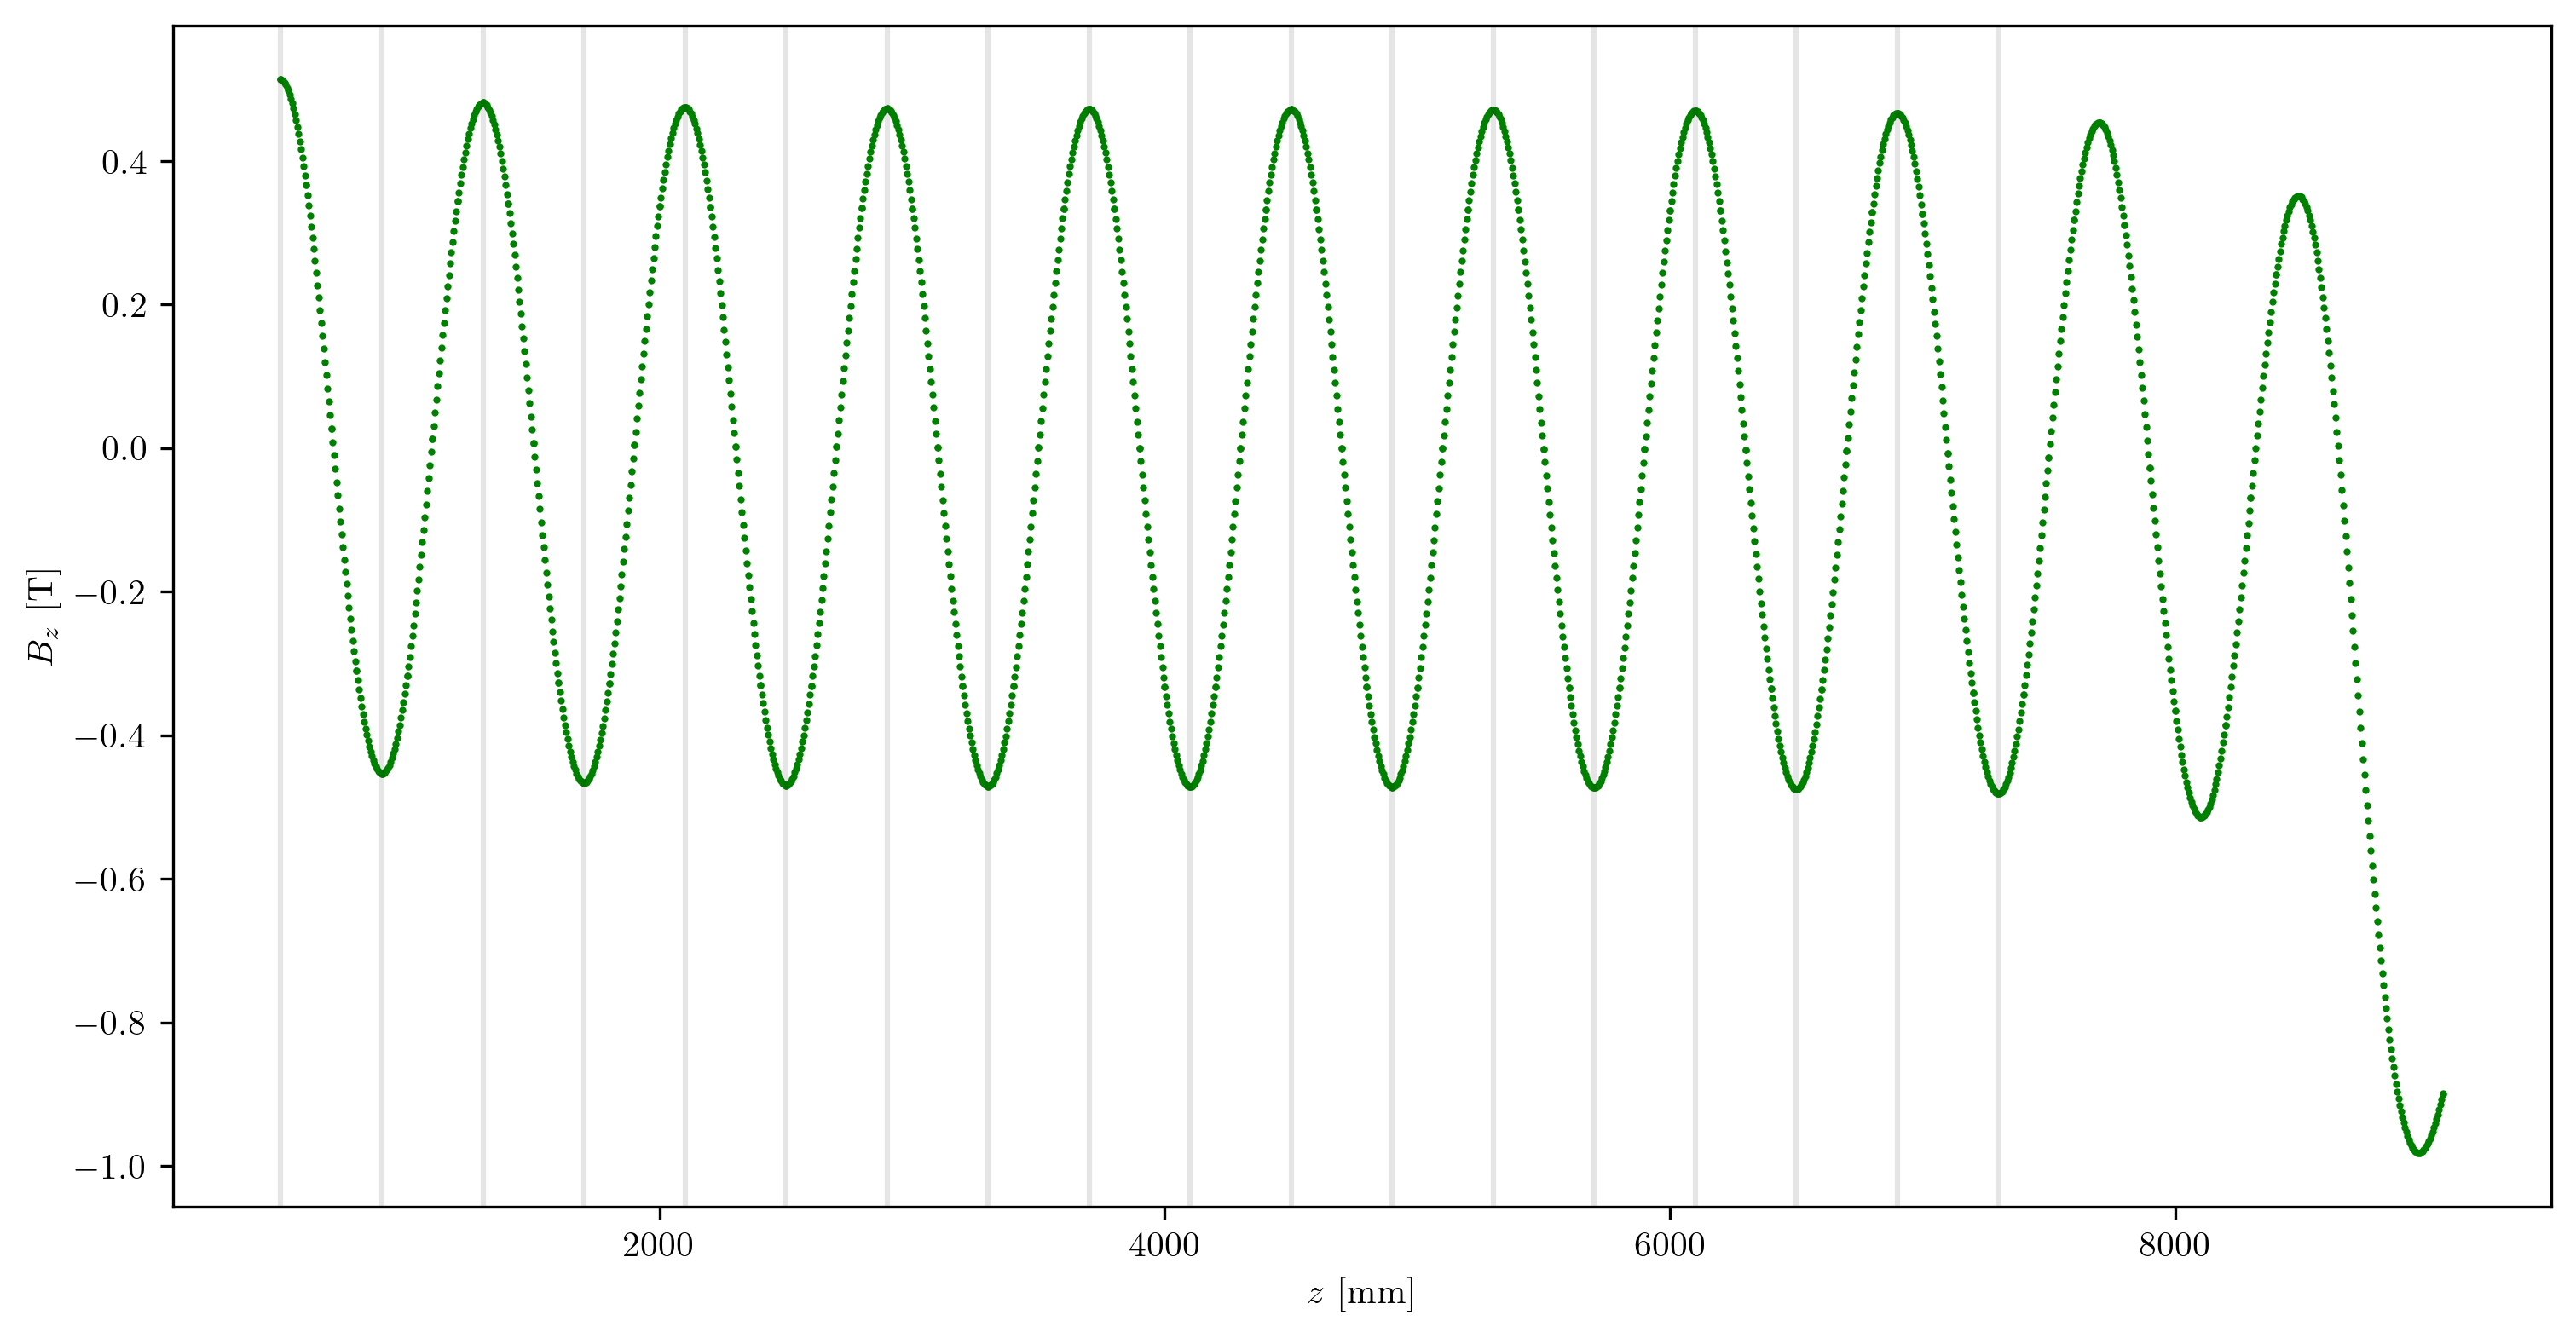

In [37]:
# Plot Bz along z:
plt.figure(figsize = (12,6))
plot_solenoids(n)
plt.scatter(data['z'],data['Bz'],color='green',s=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('$B_z$ [T]')
plt.show()

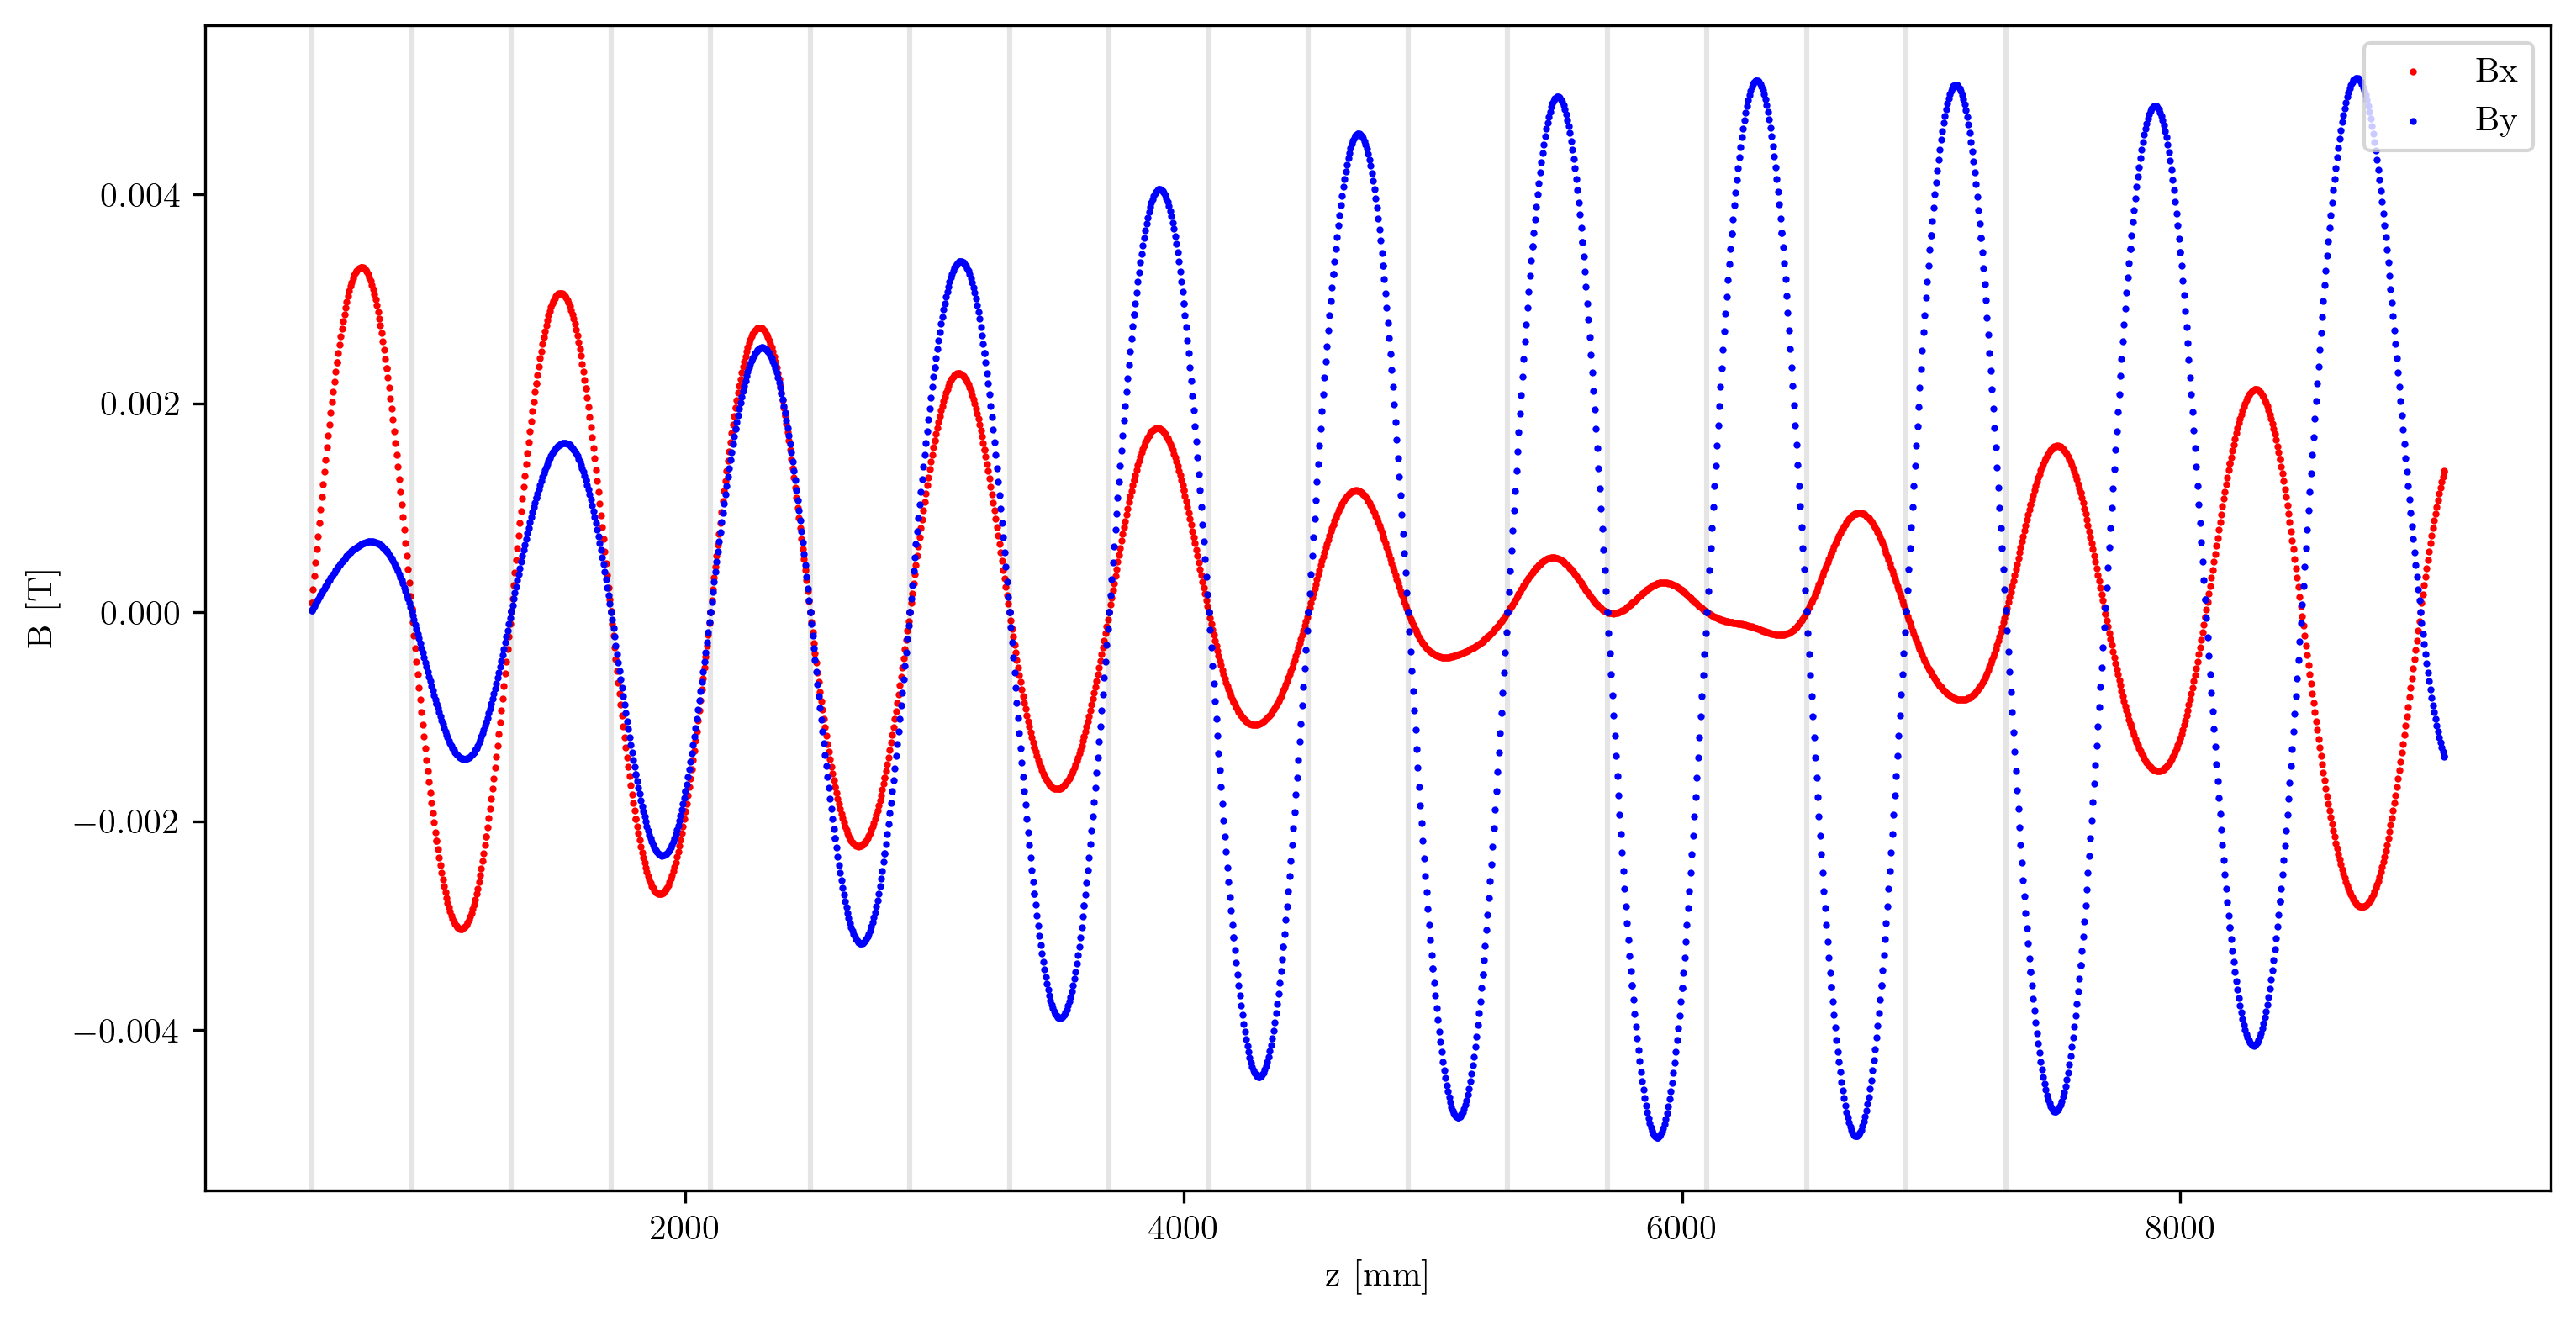

In [38]:
# Plot Bx, By along z:
plt.figure(figsize = (12,6))
plot_solenoids(n)
plt.scatter(data['z'],data['Bx'],color='red',label='Bx',s=1)
plt.scatter(data['z'],data['By'],color='blue',label='By',s=1)
plt.xlabel('z [mm]')
plt.ylabel('B [T]')
plt.legend(loc='upper right')
plt.show()

### Particle dynamics

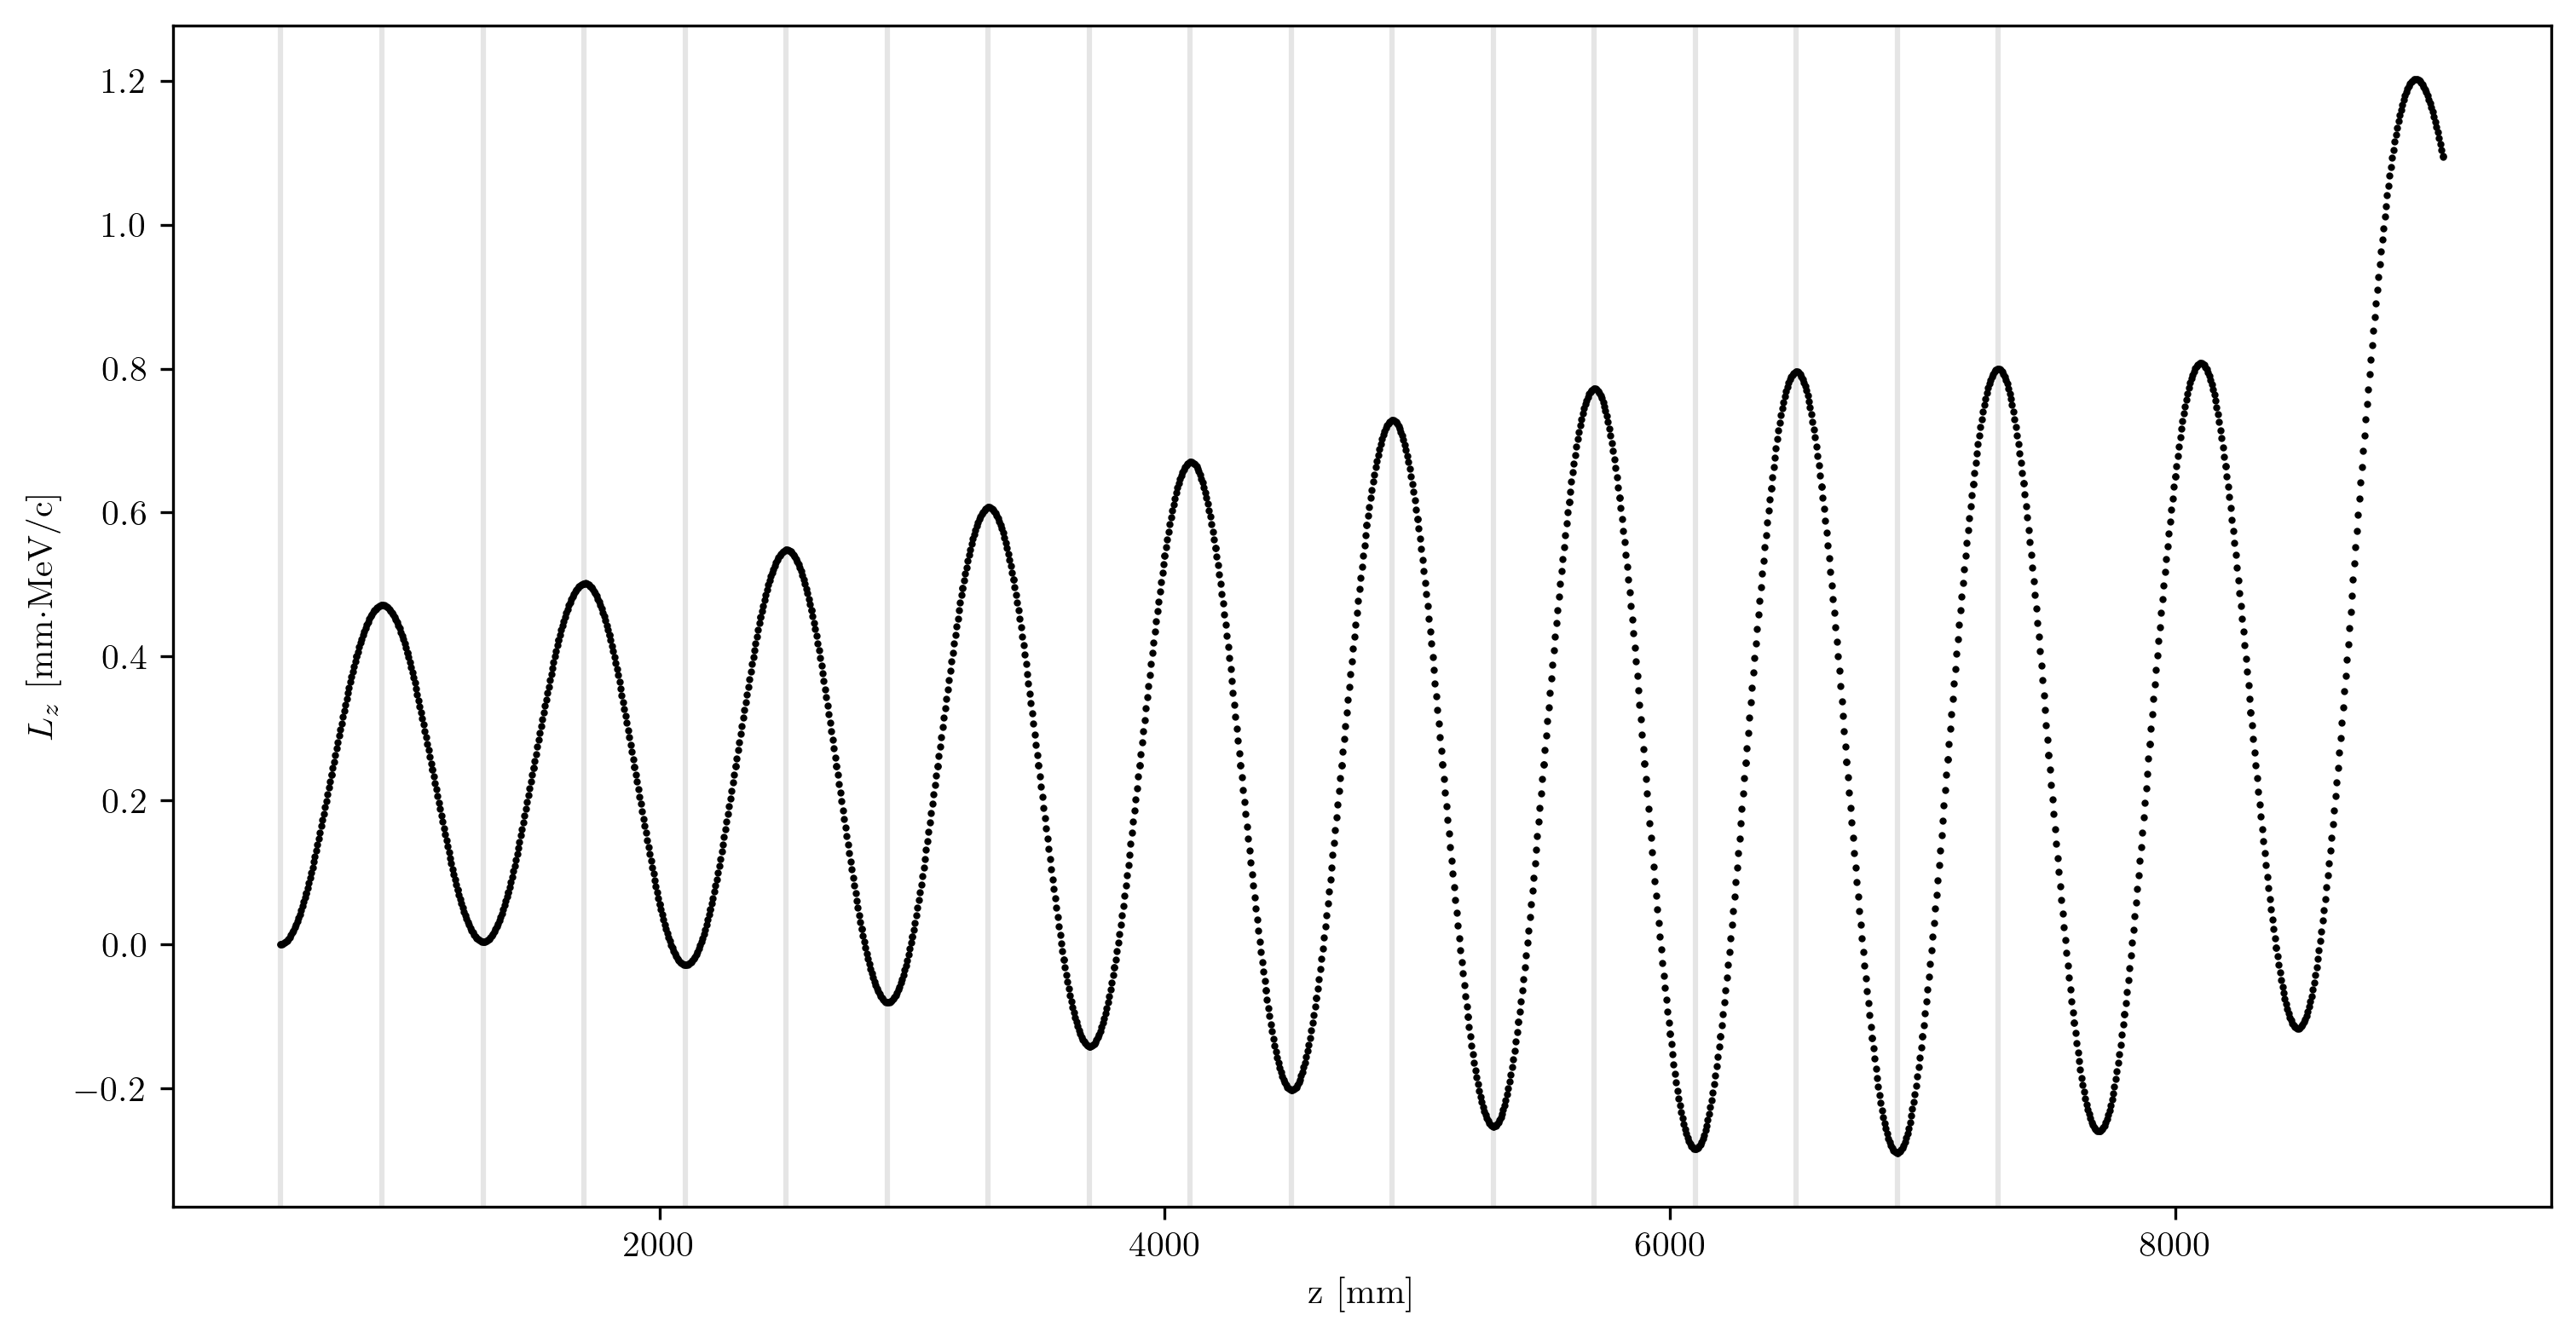

In [39]:
# Plot Lz along z:
plt.figure(figsize = (12,6))
plot_solenoids(n)
plt.scatter(data['z'],data['Lz'],color='black',s=1)
plt.xlabel('z [mm]')
plt.ylabel('$L_z$ [mm$\cdot$MeV/c]')
plt.show()

In [40]:
# Find min and max Lz:
min_Lz = np.min(data['Lz'])
max_Lz = np.max(data['Lz'])
print(f'Minimum L_z: {min_Lz}')
print(f'Maximum L_z: {max_Lz}')

Minimum L_z: -0.2895346981825
Maximum L_z: 1.20233604547


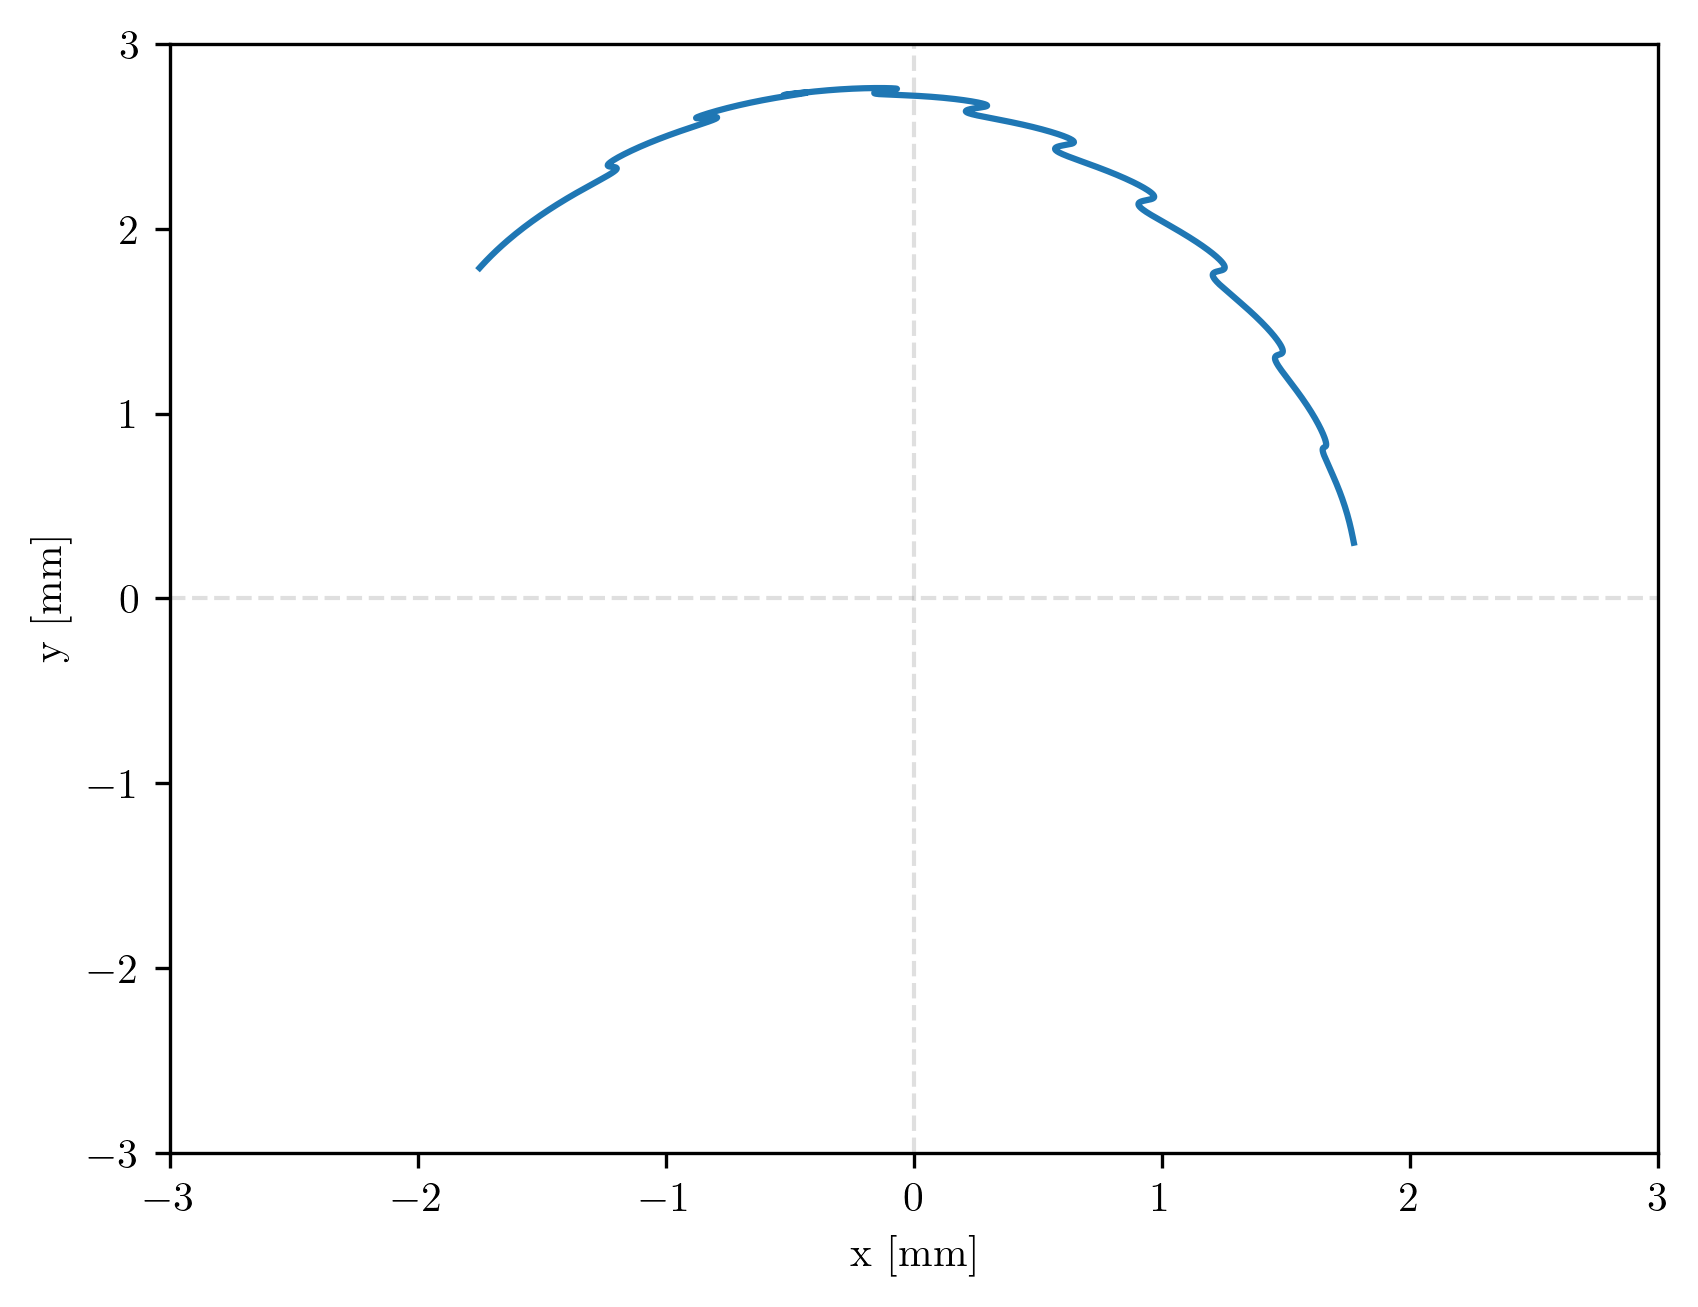

In [41]:
# Plot projection in x-y plane:
plt.figure()
plt.plot(data['x'],data['y'])
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.xticks(np.arange(-3,3.5,1))
plt.yticks(np.arange(-3,3.5,1))
plt.axhline(0, color='gray', alpha=0.25, linestyle='--', linewidth=1)
plt.axvline(0, color='gray', alpha=0.25, linestyle='--', linewidth=1)
plt.show()

### Momenta

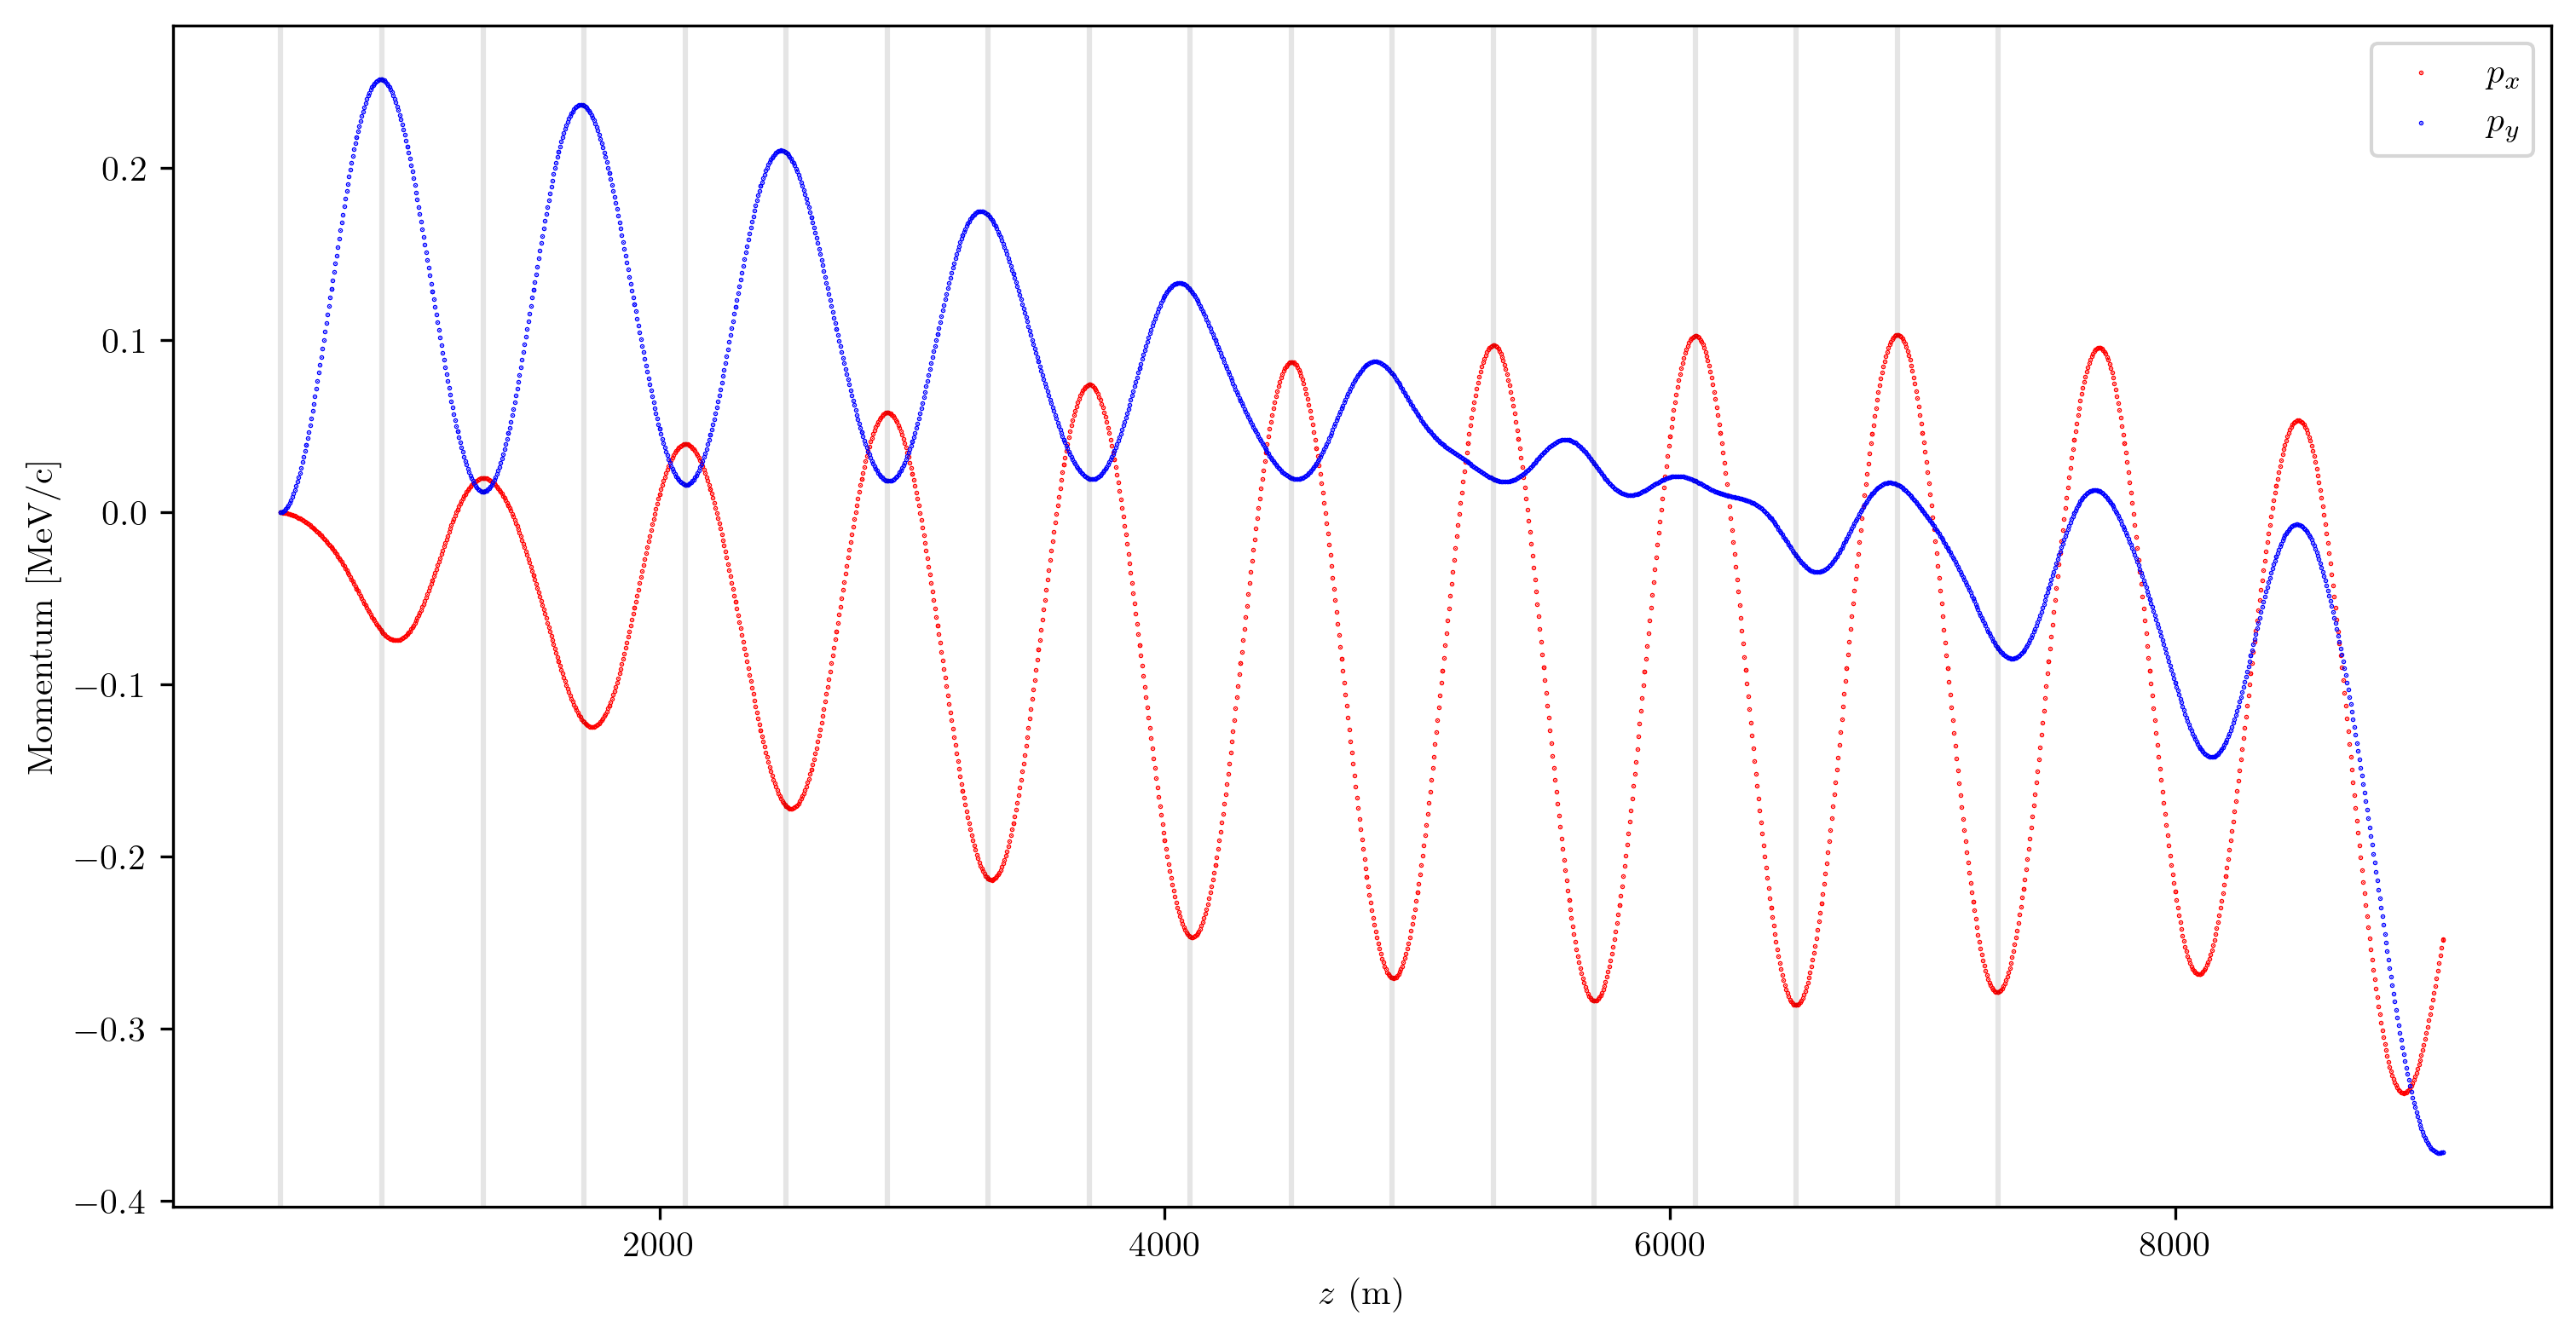

In [42]:
# Plot px, py along z:
plt.figure(figsize = (12,6))
plot_solenoids(n)
plt.scatter(data['z'],data['px'],label='$p_x$',color='red', s=0.1)
plt.scatter(data['z'],data['py'],label='$p_y$',color='blue', s=0.1)
plt.ylabel('Momentum [MeV/c]')
plt.xlabel('$z$ (m)')
plt.legend()
plt.show()

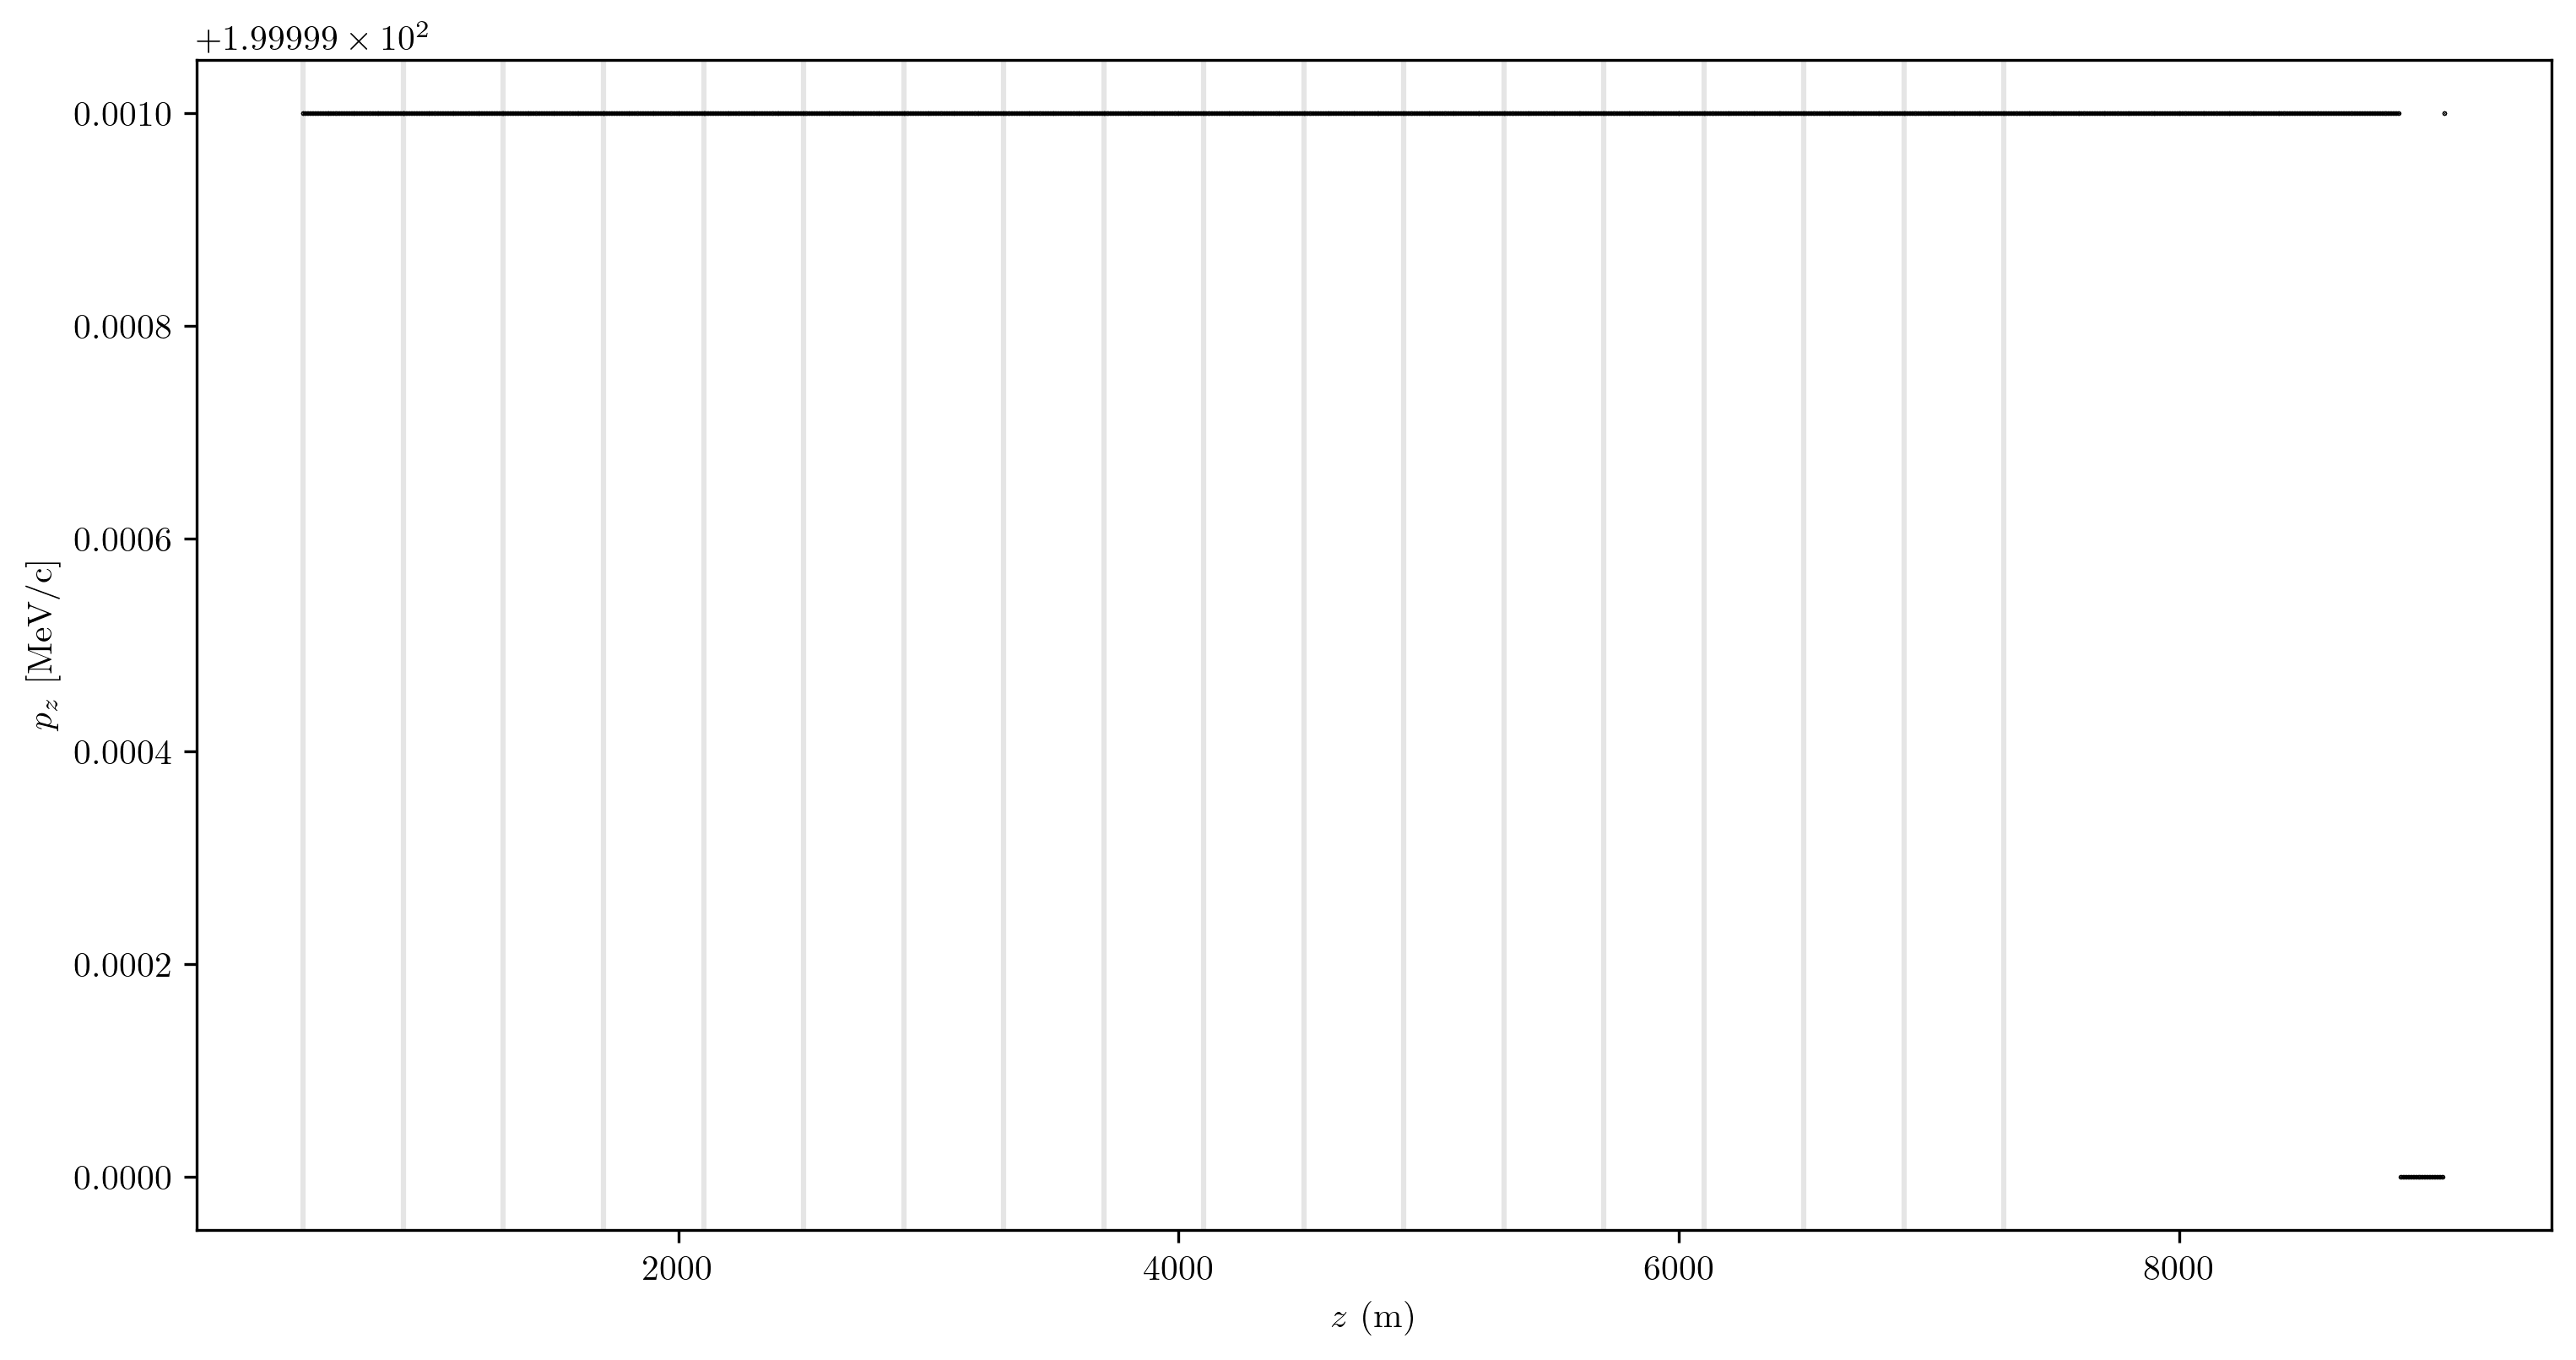

In [43]:
# Plot pz along z:
plt.figure(figsize = (12,6))
plot_solenoids(n)
plt.scatter(data['z'],data['pz'],label='$p_z$',color='black',s=0.1)
plt.ylabel('$p_z$ [MeV/c]')
plt.xlabel('$z$ (m)')
plt.show()

### Fields in rotated frame

#### Via approximation using B_z and r

In [44]:
# Compute B_r along channel -- from analytical approximation for untilted solenoids:
Br_vals_ana = calculate_Br_analytic(data)

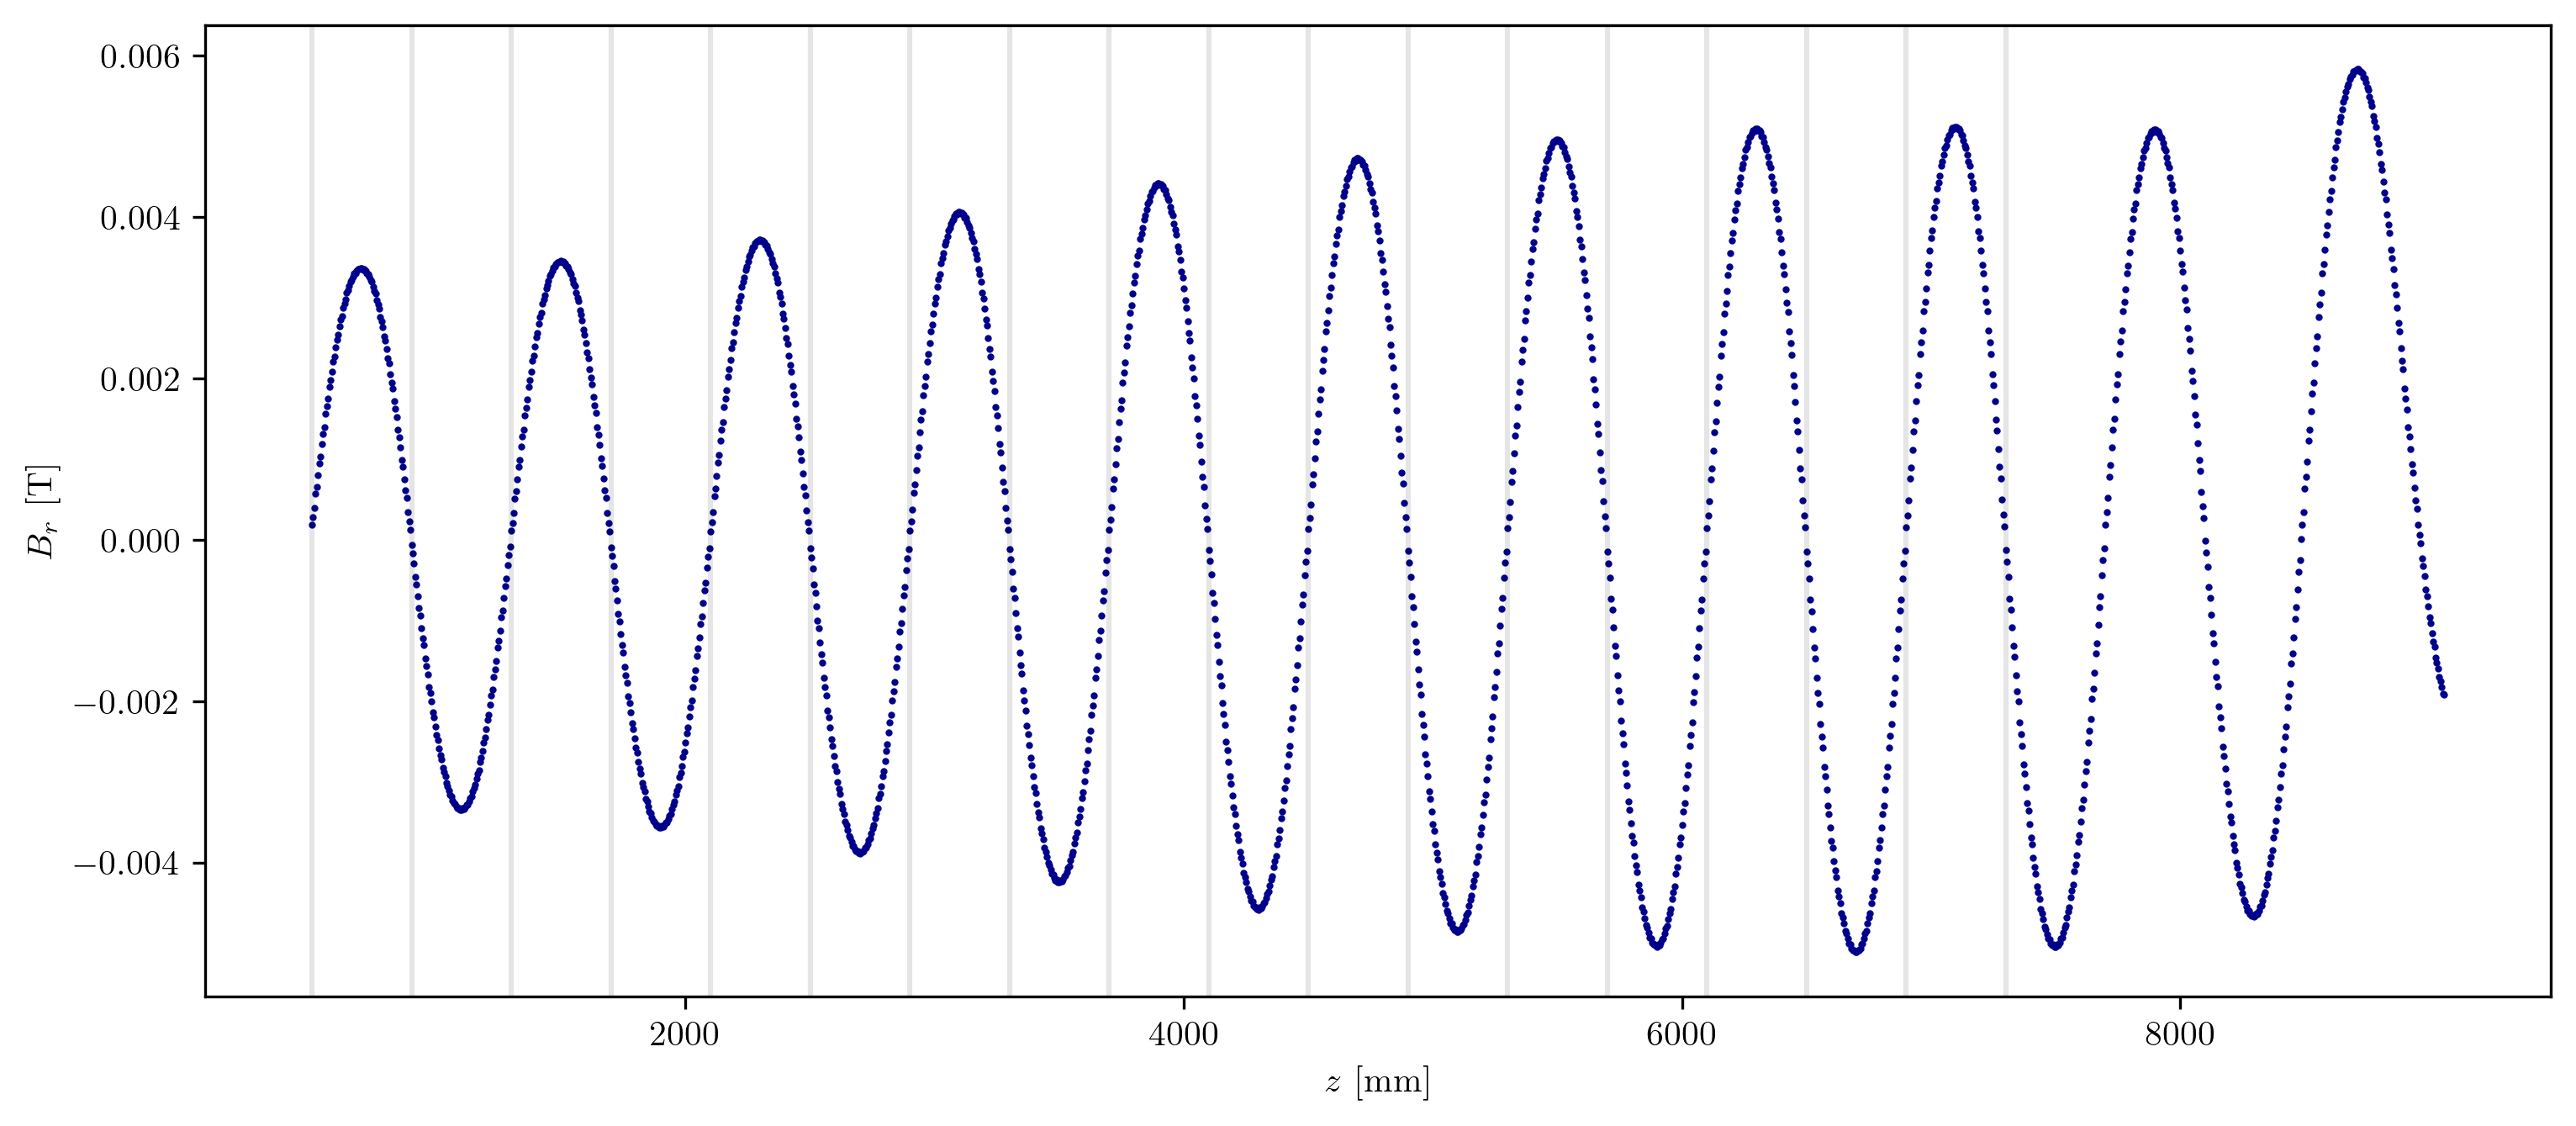

In [45]:
# Plot B_r vs. z:
plt.figure(figsize=(12,5))
plot_solenoids(n)
plt.scatter(data['z'], Br_vals_ana, s=1, color='darkblue')
plt.ylabel('$B_r$ [T]')
plt.xlabel('$z$ [mm]')
plt.show()

#### Via rotation of Cartesian components

In [46]:
# Compute B_r and B_phi along channel -- from geometrical definitions:
Br_vals_rot, Bphi_vals = calculate_Br_rotated(data)

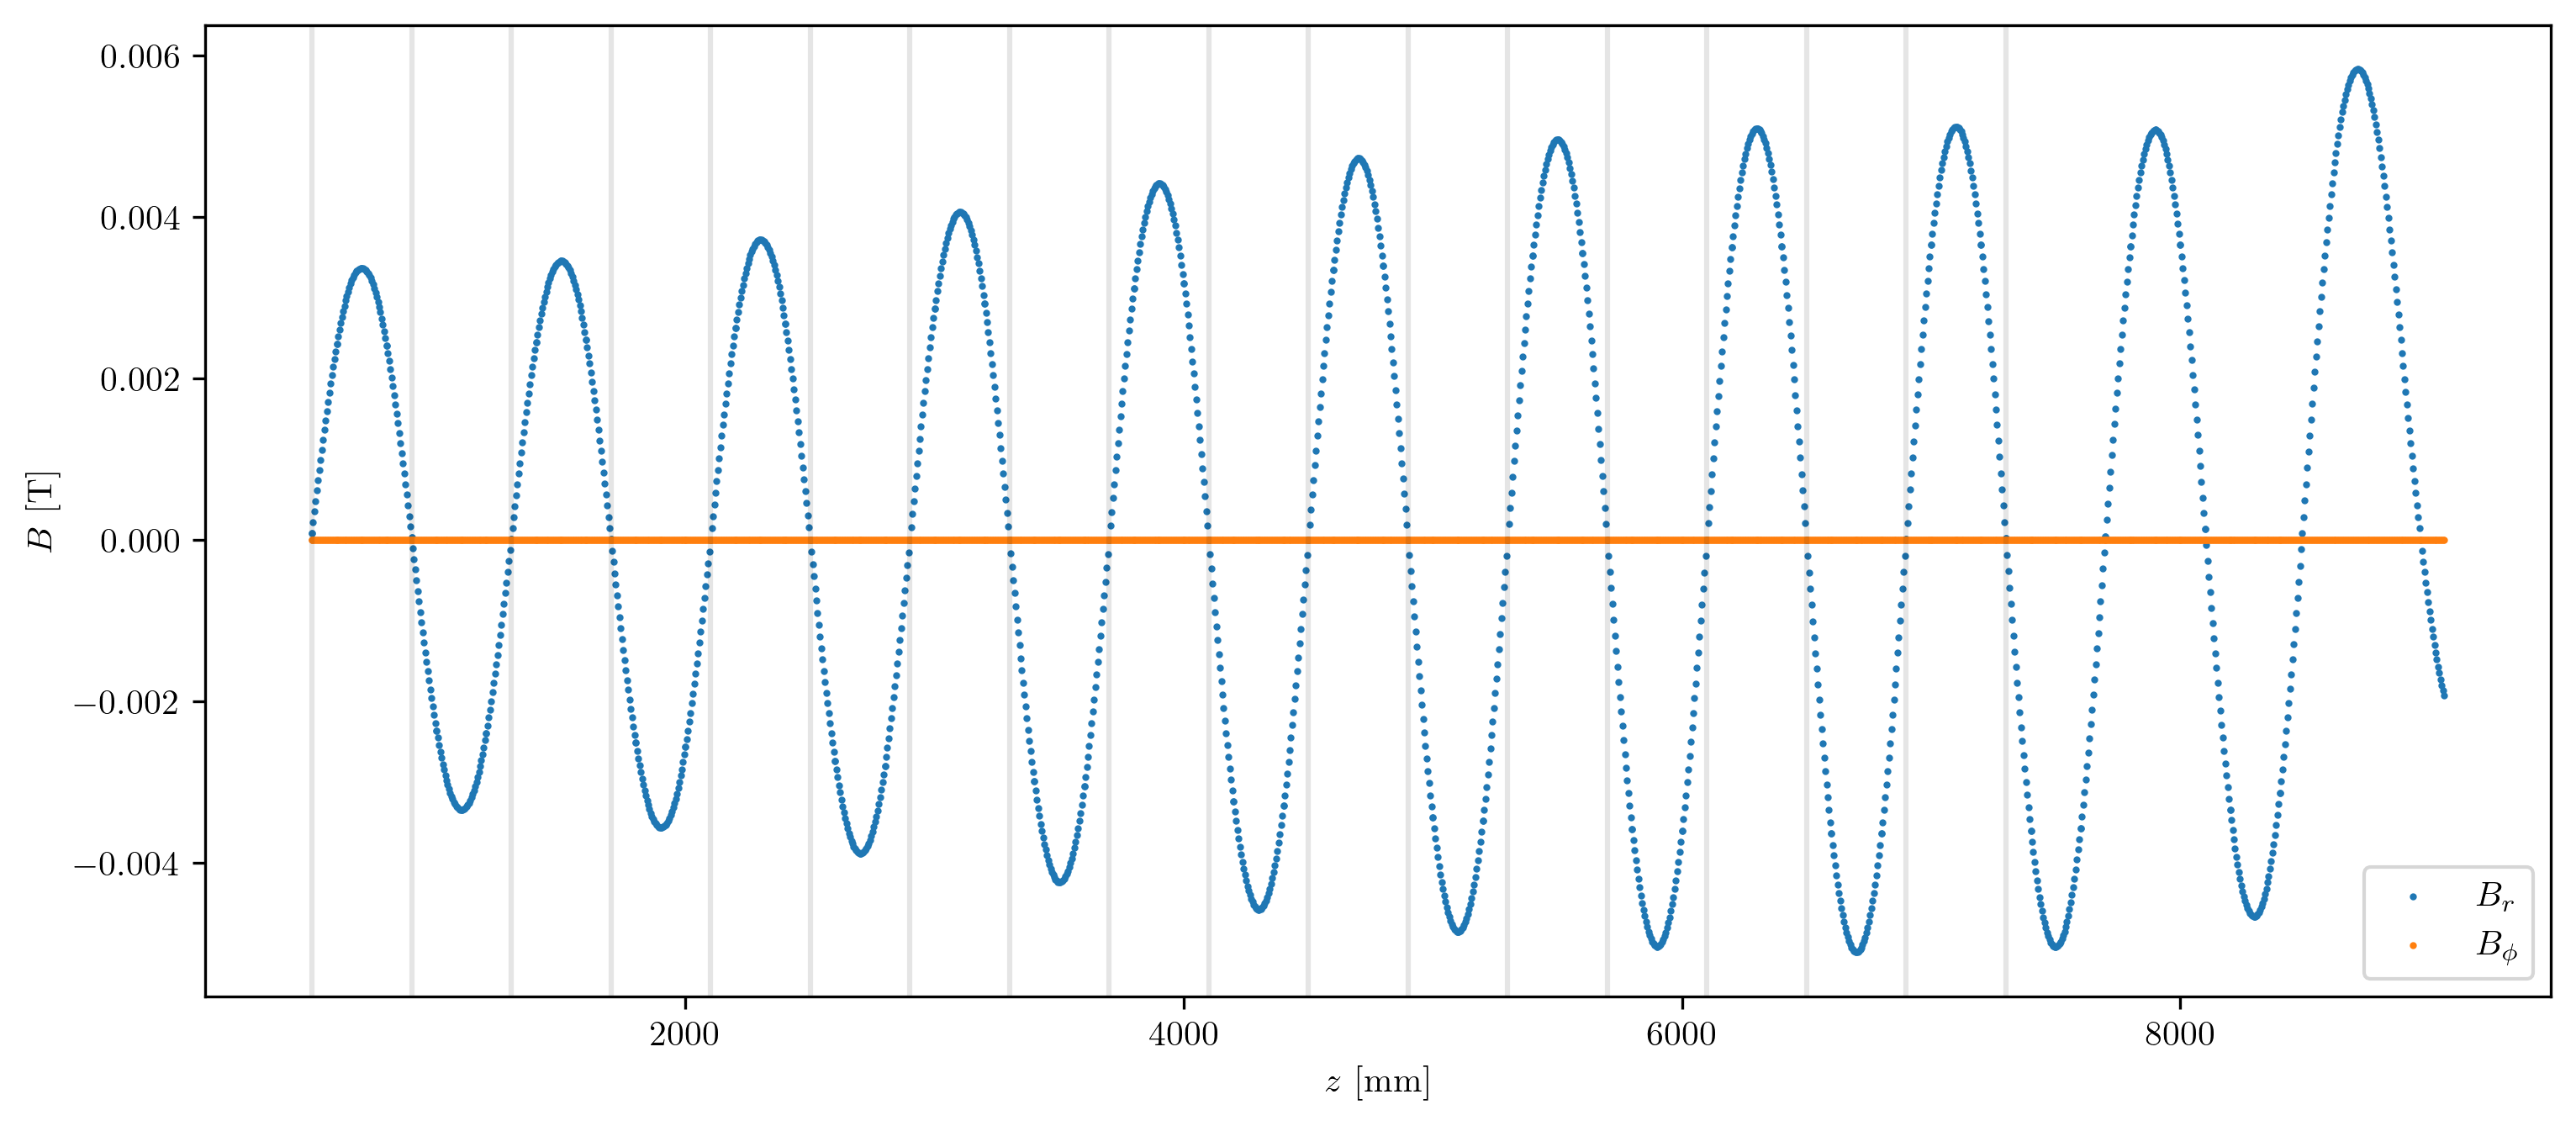

In [47]:
# Plot B_r and B_phi vs. z:
plt.figure(figsize=(12,5))
plot_solenoids(n)
plt.scatter(data['z'],Br_vals_rot,color='tab:blue',label='$B_r$', s=1)
plt.scatter(data['z'],Bphi_vals,color='tab:orange',label='$B_{\phi}$', s=1)
plt.legend()
plt.ylabel('$B$ [T]')
plt.xlabel('$z$ [mm]')
plt.show()

#### Comparison

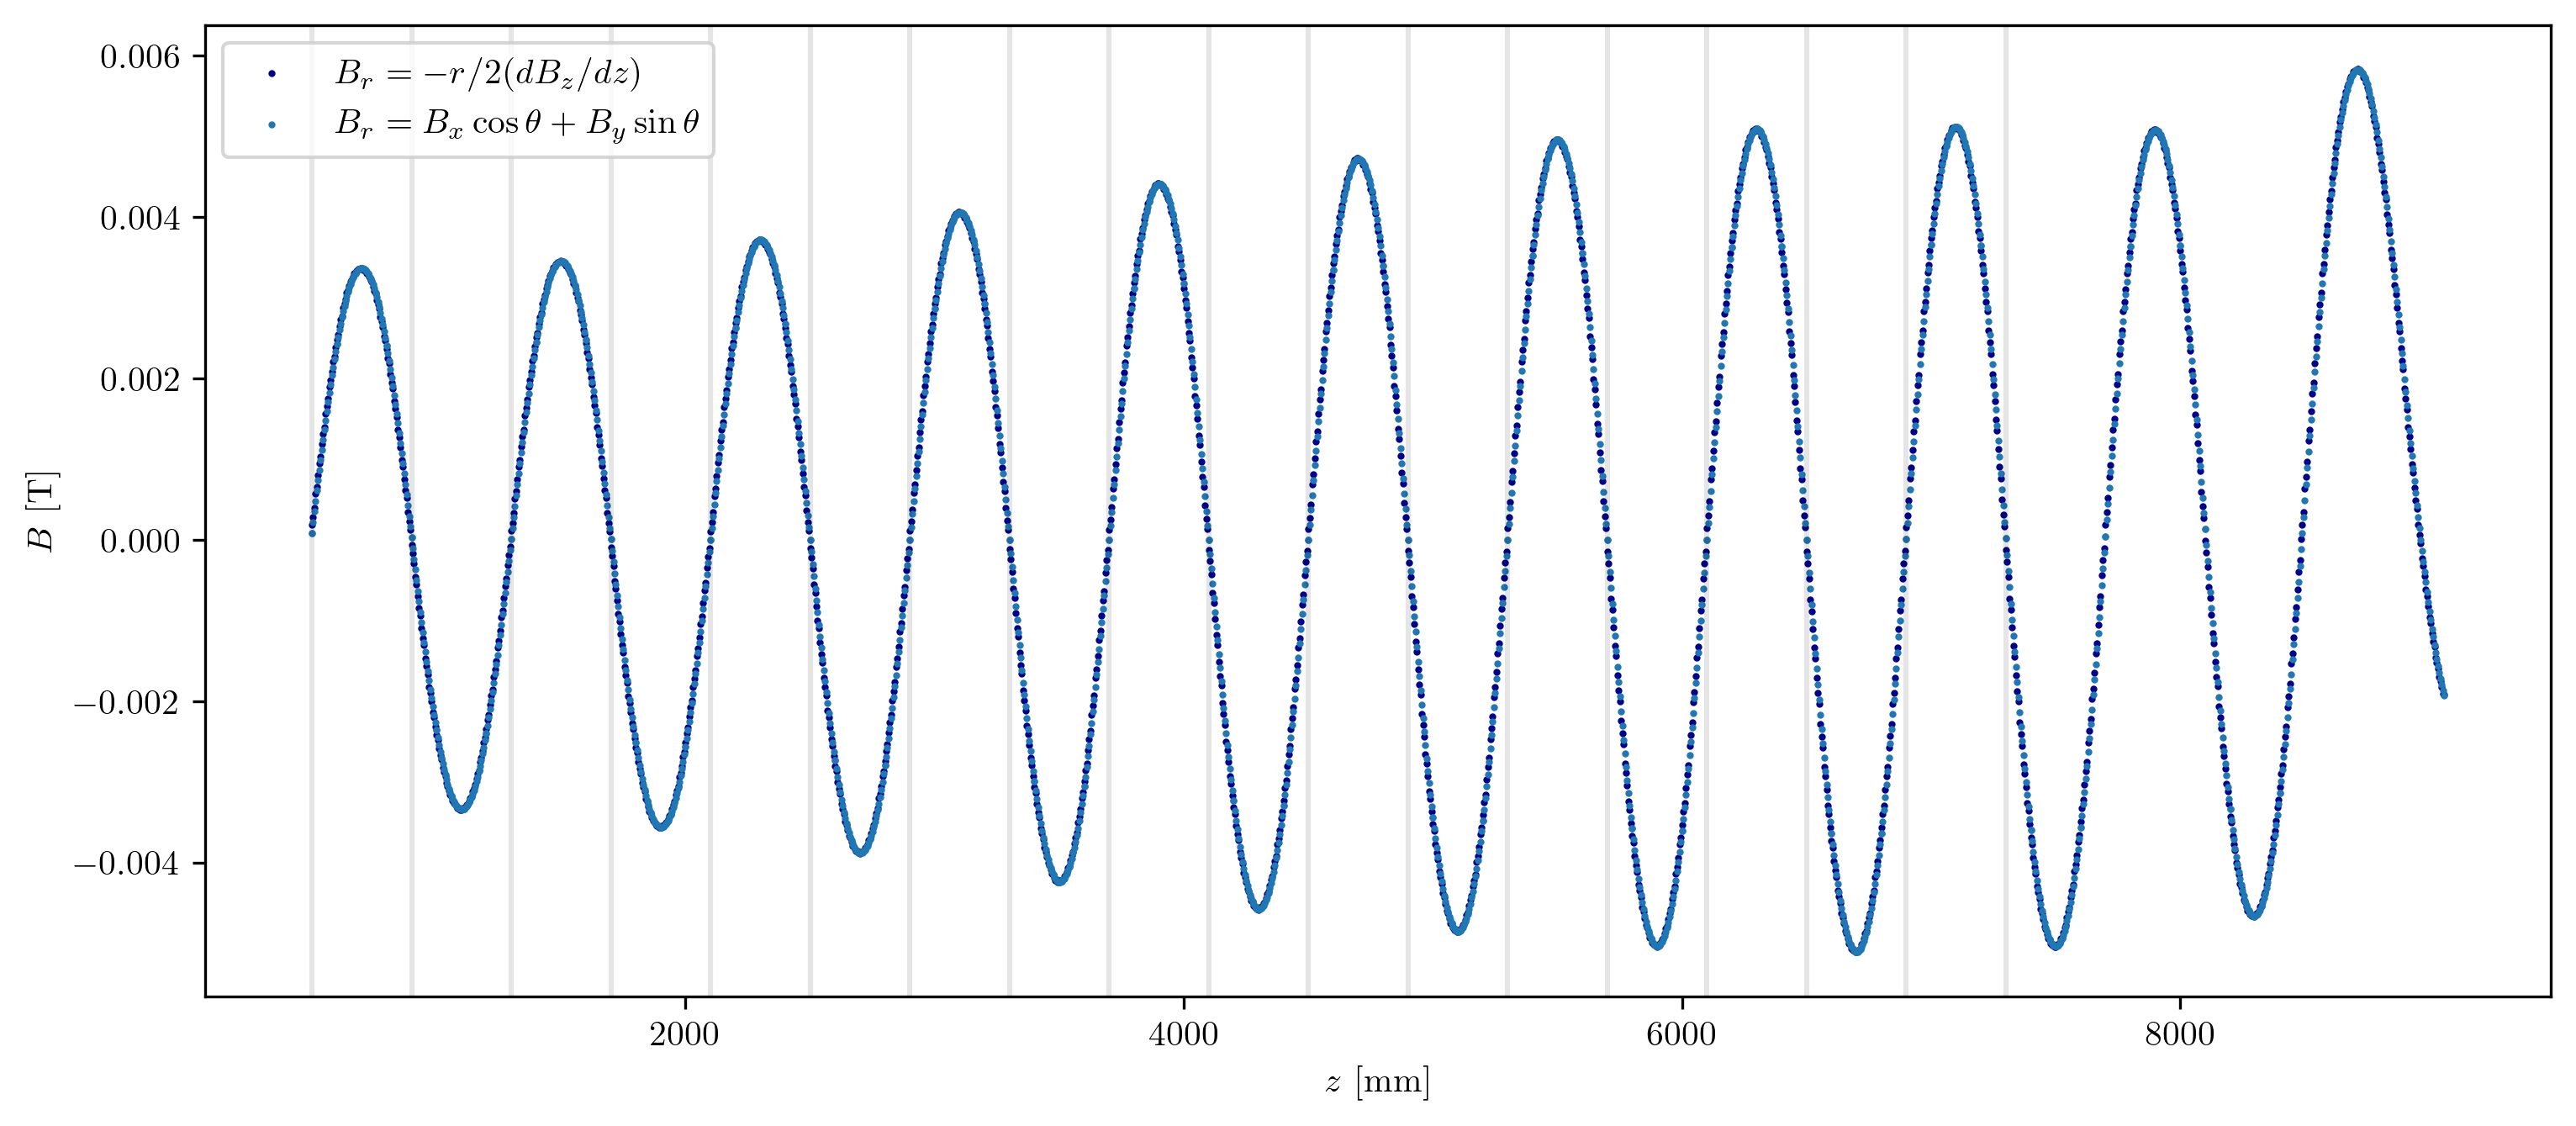

In [48]:
# Plot B_r vs. z from both approaches:
plt.figure(figsize=(12,5))
plot_solenoids(n)
plt.scatter(data['z'],Br_vals_ana,label='$ B_r = -r/2 (dB_z/dz) $',color='darkblue', s=1)
plt.scatter(data['z'],Br_vals_rot,label=r'$ B_r = B_x \cos{\theta} + B_y \sin{\theta} $',color='tab:blue', s=1)
plt.legend()
plt.ylabel('$B$ [T]')
plt.xlabel('$z$ [mm]')
plt.show()